# Comparacion DF vs Shooting vs Numerov (Litio)

Este notebook compara los estados $2s, 3s, 4s, 2p, 3p, 3d$ usando:
- Diferencias Finitas (DF) desde `finite-diferences/energias_litio_fortran.dat`
- Shooting method desde `shooting-method/energias_shooting_fortran.dat`
- Numerov (Fortran) desde `numerov/energias_numerov_fortran.dat`

Tambien se incluye la tabla de referencia del paper con columnas adicionales para las energias calculadas por DF, shooting y Numerov.

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
base = Path('.')
df_dir = base / 'finite-diferences'
shoot_dir = base / 'shooting-method'
num_dir = base / 'numerov'

f_df_e = df_dir / 'energias_litio_fortran.dat'
f_shoot_e = shoot_dir / 'energias_shooting_fortran.dat'
f_num_e = num_dir / 'energias_numerov_fortran.dat'
f_df_w = df_dir / 'funciones_radiales_litio_fortran.dat'
f_shoot_w = shoot_dir / 'funciones_shooting_fortran.dat'
f_num_w = num_dir / 'funciones_numerov_fortran.dat'

for fp in [f_df_e, f_shoot_e, f_num_e, f_df_w, f_shoot_w, f_num_w]:
    if not fp.exists():
        raise FileNotFoundError(f'No existe: {fp}')

print('OK archivos encontrados para DF, shooting y Numerov.')

OK archivos encontrados para DF, shooting y Numerov.


In [27]:
states = ['2s', '3s', '4s', '2p', '3p', '3d']

paper = pd.DataFrame({
    'Estado': ['2s', '3s', '4s', '2p', '3p', '3d'],
    'E_calc_paper_eV': [-4.6994, -1.8527, -0.7201, -3.4306, -1.5050, -1.5048],
    'E_exp_eV': [-5.39, -2.02, -1.05, -3.54, -1.56, -1.51],
    'At_Hidrogeno_eV': [-3.401, -1.512, -0.850, -3.401, -1.512, -1.512],
})

def load_energy_table(path):
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[0]
            try:
                out[label] = float(parts[-1])
            except ValueError:
                continue
    return out

df_e = load_energy_table(f_df_e)
shoot_e = load_energy_table(f_shoot_e)
num_e = load_energy_table(f_num_e)

print('Energias DF:', df_e)
print('Energias shooting:', shoot_e)
print('Energias Numerov:', num_e)

Energias DF: {'2s': -4.60305801792759, '3s': -1.83434695271664, '4s': -0.980687663111314, '2p': -3.43211895459327, '3p': -1.52229752916416, '3d': -1.51179907534784}
Energias shooting: {'2s': -2.866904276771, '3s': -1.347251606168, '4s': -0.779719651092, '2p': -3.377649032029, '3p': -1.503671438005, '3d': -1.511832472709}
Energias Numerov: {'2s': -5.287060324926, '3s': -2.132916835011, '4s': -1.3605693, '2p': -3.869676098962, '3p': -1.337272078779, '3d': -1.893643481153}


In [28]:
table = paper.copy()
table['E_DF_eV'] = table['Estado'].map(df_e)
table['E_shooting_eV'] = table['Estado'].map(shoot_e)
table['E_numerov_eV'] = table['Estado'].map(num_e)
table['Delta_DF_vs_paper'] = table['E_DF_eV'] - table['E_calc_paper_eV']
table['Delta_shoot_vs_paper'] = table['E_shooting_eV'] - table['E_calc_paper_eV']
table['Delta_num_vs_paper'] = table['E_numerov_eV'] - table['E_calc_paper_eV']

table

,Estado,E_calc_paper_eV,E_exp_eV,At_Hidrogeno_eV,E_DF_eV,E_shooting_eV,E_numerov_eV,Delta_DF_vs_paper,Delta_shoot_vs_paper,Delta_num_vs_paper
0,2s,-4.6994,-5.39,-3.401,-4.603058,-2.866904,-5.287060,0.096342,1.832496,-0.587660
1,3s,-1.8527,-2.02,-1.512,-1.834347,-1.347252,-2.132917,0.018353,0.505448,-0.280217
2,4s,-0.7201,-1.05,-0.850,-0.980688,-0.779720,-1.360569,-0.260588,-0.059620,-0.640469
3,2p,-3.4306,-3.54,-3.401,-3.432119,-3.377649,-3.869676,-0.001519,0.052951,-0.439076
4,3p,-1.5050,-1.56,-1.512,-1.522298,-1.503671,-1.337272,-0.017298,0.001329,0.167728
5,3d,-1.5048,-1.51,-1.512,-1.511799,-1.511832,-1.893643,-0.006999,-0.007032,-0.388843


In [29]:
# Error relativo de cada metodo respecto a E_calc del paper
eps = 1e-14
err_df = np.abs(table['E_DF_eV'] - table['E_calc_paper_eV']) / (np.abs(table['E_calc_paper_eV']) + eps)
err_sh = np.abs(table['E_shooting_eV'] - table['E_calc_paper_eV']) / (np.abs(table['E_calc_paper_eV']) + eps)
err_num = np.abs(table['E_numerov_eV'] - table['E_calc_paper_eV']) / (np.abs(table['E_calc_paper_eV']) + eps)

err_df = err_df.to_numpy(dtype=float)
err_sh = err_sh.to_numpy(dtype=float)
err_num = err_num.to_numpy(dtype=float)

print('Estado | err_rel(DF) | err_rel(shooting) | err_rel(Numerov)')
for st, e1, e2, e3 in zip(table['Estado'], err_df, err_sh, err_num):
    print(f"{st:>3} | {e1:>10.4e} | {e2:>10.4e} | {e3:>10.4e}")

Estado | err_rel(DF) | err_rel(shooting) | err_rel(Numerov)
 2s | 2.0501e-02 | 3.8994e-01 | 1.2505e-01
 3s | 9.9061e-03 | 2.7282e-01 | 1.5125e-01
 4s | 3.6188e-01 | 8.2794e-02 | 8.8942e-01
 2p | 4.4277e-04 | 1.5435e-02 | 1.2799e-01
 3p | 1.1493e-02 | 8.8277e-04 | 1.1145e-01
 3d | 4.6512e-03 | 4.6734e-03 | 2.5840e-01


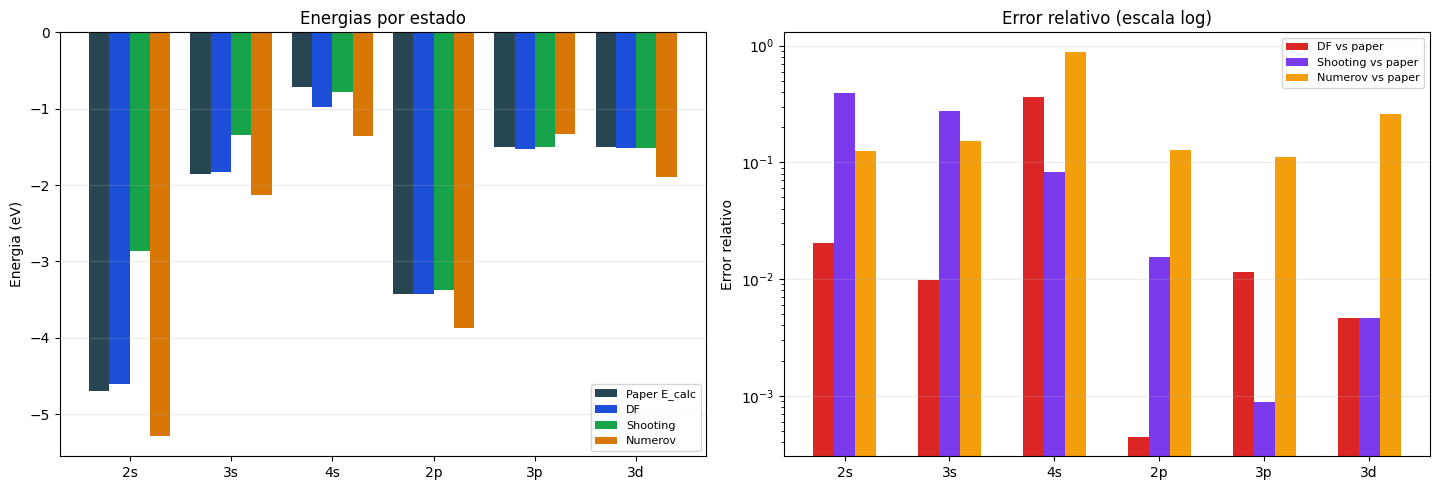

In [30]:
x = np.arange(len(states))
w = 0.20

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.0))

ax[0].bar(x - 1.5*w, table['E_calc_paper_eV'], width=w, label='Paper E_calc', color='#264653')
ax[0].bar(x - 0.5*w, table['E_DF_eV'], width=w, label='DF', color='#1d4ed8')
ax[0].bar(x + 0.5*w, table['E_shooting_eV'], width=w, label='Shooting', color='#16a34a')
ax[0].bar(x + 1.5*w, table['E_numerov_eV'], width=w, label='Numerov', color='#d97706')
ax[0].set_xticks(x)
ax[0].set_xticklabels(states)
ax[0].set_ylabel('Energia (eV)')
ax[0].set_title('Energias por estado')
ax[0].grid(True, axis='y', alpha=0.25)
ax[0].legend(fontsize=8)

ax[1].bar(x - w, err_df, width=w, label='DF vs paper', color='#dc2626')
ax[1].bar(x, err_sh, width=w, label='Shooting vs paper', color='#7c3aed')
ax[1].bar(x + w, err_num, width=w, label='Numerov vs paper', color='#f59e0b')
ax[1].set_xticks(x)
ax[1].set_xticklabels(states)
ax[1].set_yscale('log')
ax[1].set_ylabel('Error relativo')
ax[1].set_title('Error relativo (escala log)')
ax[1].grid(True, axis='y', alpha=0.25)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
def load_wave_columns(path):
    arr = np.loadtxt(path, comments='#')
    return arr[:, 0], arr

# DF: r, R_2s, R_3s, R_4s, R_2p, R_3p, R_3d
r_df, wf_df = load_wave_columns(f_df_w)
R_df = {
    '2s': wf_df[:, 1],
    '3s': wf_df[:, 2],
    '4s': wf_df[:, 3],
    '2p': wf_df[:, 4],
    '3p': wf_df[:, 5],
    '3d': wf_df[:, 6],
}

# Shooting: r, R_2s, R_3s, R_4s, R_2p, R_3p, R_3d
r_sh, wf_sh = load_wave_columns(f_shoot_w)
R_sh = {
    '2s': wf_sh[:, 1],
    '3s': wf_sh[:, 2],
    '4s': wf_sh[:, 3],
    '2p': wf_sh[:, 4],
    '3p': wf_sh[:, 5],
    '3d': wf_sh[:, 6],
}

# Numerov: r, R_2s, R_3s, R_4s, R_2p, R_3p, R_3d
r_num, wf_num = load_wave_columns(f_num_w)
R_num = {
    '2s': wf_num[:, 1],
    '3s': wf_num[:, 2],
    '4s': wf_num[:, 3],
    '2p': wf_num[:, 4],
    '3p': wf_num[:, 5],
    '3d': wf_num[:, 6],
}

mask_df = (r_df >= 0.0) & (r_df <= 25.0)
mask_sh = (r_sh >= 0.0) & (r_sh <= 25.0)
mask_num = (r_num >= 0.0) & (r_num <= 25.0)

print('Max |R(r)| en 0<=r<=25 (DF / shooting / Numerov):')
for st in states:
    m_df = np.max(np.abs(R_df[st][mask_df]))
    m_sh = np.max(np.abs(R_sh[st][mask_sh]))
    m_num = np.max(np.abs(R_num[st][mask_num]))
    print(f"{st:>3}: DF={m_df:.3e}  shoot={m_sh:.3e}  num={m_num:.3e}")

Max |R(r)| en 0<=r<=25 (DF / shooting / Numerov):
 2s: DF=5.026e-01  shoot=1.421e-15  num=2.785e-01
 3s: DF=3.485e-01  shoot=1.508e-07  num=2.899e-01
 4s: DF=2.712e-01  shoot=4.600e-04  num=2.962e-01
 2p: DF=4.431e-01  shoot=2.069e-18  num=2.766e-01
 3p: DF=3.198e-01  shoot=2.885e-09  num=3.006e-01
 3d: DF=3.272e-01  shoot=9.994e-10  num=2.773e-01


## Comparacion de funciones radiales: DF vs Shooting vs Numerov

Panel A muestra estados s y Panel B estados p.

El estado 3d se conserva en la tabla de energias, pero no se muestra en esta figura para mantener la comparacion visual centrada en s y p.

Para comparar forma (y evitar que una curva quede visualmente pegada al cero), cada curva se reescala por su maximo absoluto en la ventana mostrada $0 \le r \le 25$ u.a.

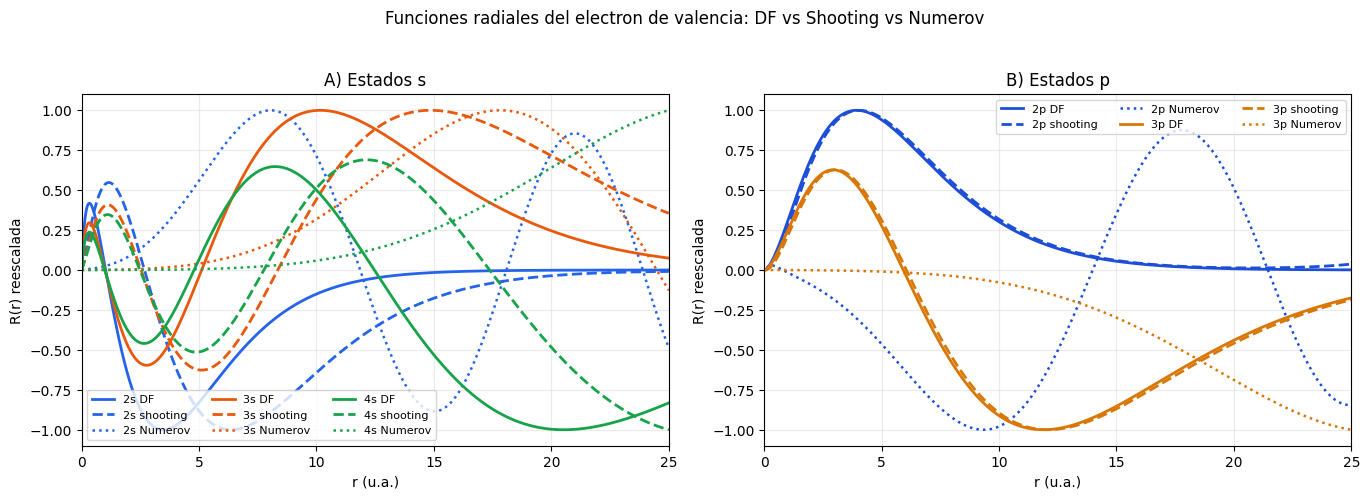

In [32]:
def normalize_in_window(r, y, rmin=0.0, rmax=25.0):
    m = (r >= rmin) & (r <= rmax)
    scale = np.max(np.abs(y[m]))
    if not np.isfinite(scale) or scale <= 0.0:
        return y
    return y / scale

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), sharex=True)

# Estados s
for st, col in [('2s', '#2563eb'), ('3s', '#ea580c'), ('4s', '#16a34a')]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    y_num = normalize_in_window(r_num, R_num[st])
    axes[0].plot(r_df, y_df, color=col, lw=2.0, label=f'{st} DF')
    axes[0].plot(r_sh, y_sh, color=col, lw=2.0, ls='--', label=f'{st} shooting')
    axes[0].plot(r_num, y_num, color=col, lw=1.8, ls=':', label=f'{st} Numerov')

axes[0].set_xlim(0.0, 25.0)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r) reescalada')
axes[0].set_title('A) Estados s')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=3)

# Estados p
for st, col in [('2p', '#1d4ed8'), ('3p', '#d97706')]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    y_num = normalize_in_window(r_num, R_num[st])
    axes[1].plot(r_df, y_df, color=col, lw=2.0, label=f'{st} DF')
    axes[1].plot(r_sh, y_sh, color=col, lw=2.0, ls='--', label=f'{st} shooting')
    axes[1].plot(r_num, y_num, color=col, lw=1.8, ls=':', label=f'{st} Numerov')

axes[1].set_xlim(0.0, 25.0)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r) reescalada')
axes[1].set_title('B) Estados p')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, ncol=3)

plt.suptitle('Funciones radiales del electron de valencia: DF vs Shooting vs Numerov', y=1.03)
plt.tight_layout()
plt.show()